# 0. Install and Import Dependencies

In [1]:
!pip list

Package                   Version
------------------------- --------------
absl-py                   2.3.1
altair                    5.5.0
anyio                     4.11.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.3.0
asttokens                 3.0.0
astunparse                1.6.3
async-lru                 2.0.5
attrs                     25.4.0
babel                     2.17.0
beautifulsoup4            4.14.2
bleach                    6.2.0
blinker                   1.9.0
cachetools                6.2.0
certifi                   2025.10.5
cffi                      2.0.0
charset-normalizer        3.4.3
click                     8.3.0
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.17
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema            2.21.2
filelock                  3.20.0
flatbuffers    

In [2]:
!pip install opencv-python matplotlib imageio gdown tensorflow

In [2]:
import os
import cv2
import tensorflow as tf
import numpy as np
from typing import List
from matplotlib import pyplot as plt
import imageio

2025-10-11 07:10:26.781296: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-11 07:10:26.784710: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-11 07:10:27.099650: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-11 07:10:28.379030: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [5]:
tf.config.list_physical_devices('GPU')

2025-10-10 17:32:40.743732: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


[]

In [6]:
physical_devices = tf.config.list_physical_devices('GPU')
try:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
except:
    pass

# 1. Build Data Loading Functions

In [3]:
import gdown

In [4]:
url = 'https://drive.google.com/uc?id=1YlvpDLix3S-U8fd-gqRwPcWXAXm8JwjL'
output = 'data.zip'
gdown.download(url, output, quiet=False)
gdown.extractall('data.zip')

Downloading...
From (original): https://drive.google.com/uc?id=1YlvpDLix3S-U8fd-gqRwPcWXAXm8JwjL
From (redirected): https://drive.google.com/uc?id=1YlvpDLix3S-U8fd-gqRwPcWXAXm8JwjL&confirm=t&uuid=440755d5-9d96-4d37-acb6-9b090487b7b2
To: /home/ritik/Desktop/GenAthon/SilentSpeechAI/LipNet/data.zip
  0%|                                                                                   | 0.00/423M [00:00<?, ?B/s]

KeyboardInterrupt: 

In [4]:
def load_video(path: str) -> List[float]: 
    cap = cv2.VideoCapture(path)
    frames = []
    for _ in range(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))): 
        ret, frame = cap.read()
        frame = tf.image.rgb_to_grayscale(frame)
        frames.append(frame[190:236, 80:220, :])
    cap.release()
    
    mean = tf.math.reduce_mean(frames)
    std = tf.math.reduce_std(tf.cast(frames, tf.float32))
    return tf.cast((frames - mean), tf.float32) / std

In [5]:
vocab = [x for x in "abcdefghijklmnopqrstuvwxyz'?!123456789 "]

In [6]:
char_to_num = tf.keras.layers.StringLookup(vocabulary=vocab, oov_token="")
num_to_char = tf.keras.layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(), oov_token="", invert=True
)

print(
    f"The vocabulary is: {char_to_num.get_vocabulary()} "
    f"(size ={char_to_num.vocabulary_size()})"
)

The vocabulary is: ['', np.str_('a'), np.str_('b'), np.str_('c'), np.str_('d'), np.str_('e'), np.str_('f'), np.str_('g'), np.str_('h'), np.str_('i'), np.str_('j'), np.str_('k'), np.str_('l'), np.str_('m'), np.str_('n'), np.str_('o'), np.str_('p'), np.str_('q'), np.str_('r'), np.str_('s'), np.str_('t'), np.str_('u'), np.str_('v'), np.str_('w'), np.str_('x'), np.str_('y'), np.str_('z'), np.str_("'"), np.str_('?'), np.str_('!'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9'), np.str_(' ')] (size =40)


2025-10-11 07:10:37.287184: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
char_to_num.get_vocabulary()

['',
 np.str_('a'),
 np.str_('b'),
 np.str_('c'),
 np.str_('d'),
 np.str_('e'),
 np.str_('f'),
 np.str_('g'),
 np.str_('h'),
 np.str_('i'),
 np.str_('j'),
 np.str_('k'),
 np.str_('l'),
 np.str_('m'),
 np.str_('n'),
 np.str_('o'),
 np.str_('p'),
 np.str_('q'),
 np.str_('r'),
 np.str_('s'),
 np.str_('t'),
 np.str_('u'),
 np.str_('v'),
 np.str_('w'),
 np.str_('x'),
 np.str_('y'),
 np.str_('z'),
 np.str_("'"),
 np.str_('?'),
 np.str_('!'),
 np.str_('1'),
 np.str_('2'),
 np.str_('3'),
 np.str_('4'),
 np.str_('5'),
 np.str_('6'),
 np.str_('7'),
 np.str_('8'),
 np.str_('9'),
 np.str_(' ')]

In [8]:
char_to_num(['n','i','c','k'])

<tf.Tensor: shape=(4,), dtype=int64, numpy=array([14,  9,  3, 11])>

In [9]:
num_to_char([14,  9,  3, 11])

<tf.Tensor: shape=(4,), dtype=string, numpy=array([b'n', b'i', b'c', b'k'], dtype=object)>

In [10]:
def load_alignments(path: str) -> List[str]: 
    with open(path, 'r') as f: 
        lines = f.readlines() 
    tokens = []
    for line in lines:
        line = line.split()
        if line[2] != 'sil': 
            tokens = [*tokens, ' ', line[2]]
    return char_to_num(tf.reshape(tf.strings.unicode_split(tokens, input_encoding='UTF-8'), (-1)))[1:]


In [11]:
def load_data(path: str): 
    path = bytes.decode(path.numpy())
    
    # FIXED: Use os.path.basename for cross-platform compatibility
    file_name = os.path.basename(path).split('.')[0]
    
    video_path = os.path.join('data', 's1', f'{file_name}.mpg')
    alignment_path = os.path.join('data', 'alignments', 's1', f'{file_name}.align')
    
    frames = load_video(video_path) 
    alignments = load_alignments(alignment_path)
    
    return frames, alignments

In [12]:
test_path = './data/s1/bbal6n.mpg'

In [13]:
tf.convert_to_tensor(test_path).numpy().decode('utf-8').split('/')[-1].split('.')[0]

'bbal6n'

In [14]:
frames, alignments = load_data(tf.convert_to_tensor(test_path))
print(f"Frames shape: {frames.shape}")
print(f"Alignments: {alignments}")


Frames shape: (75, 46, 140, 1)
Alignments: [ 2  9 14 39  2 12 21  5 39  1 20 39 12 39 19  9 24 39 14 15 23]


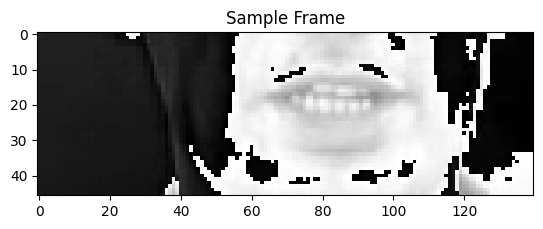

In [15]:
plt.imshow(frames[40].numpy().squeeze(), cmap='gray')
plt.title("Sample Frame")
plt.show()

In [16]:
print("Alignment text:", tf.strings.reduce_join([bytes.decode(x) for x in num_to_char(alignments.numpy()).numpy()]))

Alignment text: tf.Tensor(b'bin blue at l six now', shape=(), dtype=string)


In [17]:
tf.strings.reduce_join([bytes.decode(x) for x in num_to_char(alignments.numpy()).numpy()])

<tf.Tensor: shape=(), dtype=string, numpy=b'bin blue at l six now'>

In [18]:
def mappable_function(path: str) -> List[str]:
    result = tf.py_function(load_data, [path], (tf.float32, tf.int64))
    return result

# 2. Create Data Pipeline

In [19]:
from matplotlib import pyplot as plt

In [20]:
data = tf.data.Dataset.list_files('./data/s1/*.mpg')
data = data.shuffle(500, reshuffle_each_iteration=False)
data = data.map(mappable_function)
data = data.padded_batch(2, padded_shapes=([75, None, None, None], [40]))
data = data.prefetch(tf.data.AUTOTUNE)

# Split into train and test
train = data.take(450)
test = data.skip(450)

In [21]:
len(test)

50

In [22]:
frames, alignments = data.as_numpy_iterator().next()

In [23]:
len(frames)

2

In [24]:
sample = data.as_numpy_iterator()
val = sample.next()

In [25]:
print(f"Video batch shape: {val[0].shape}")
print(f"Alignment batch shape: {val[1].shape}")

Video batch shape: (2, 75, 46, 140, 1)
Alignment batch shape: (2, 40)


In [26]:
frames_to_save = val[0][0]  # First video in batch
frames_min = frames_to_save.min()
frames_max = frames_to_save.max()
frames_uint8 = ((frames_to_save - frames_min) / (frames_max - frames_min) * 255).astype(np.uint8)
# Remove the channel dimension (shape: [75, 46, 140, 1] -> [75, 46, 140])
frames_uint8 = frames_uint8.squeeze()

imageio.mimsave('./animation.gif', frames_uint8, fps=10)
print("Animation saved as animation.gif")

Animation saved as animation.gif


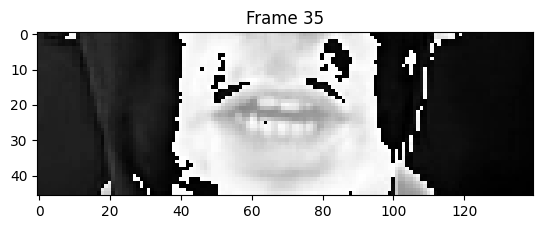

In [27]:
# 0:videos, 0: 1st video out of the batch,  0: return the first frame in the video 
plt.imshow(val[0][0][35].squeeze(), cmap='gray')
plt.title("Frame 35")
plt.show()

In [28]:
print("Alignment:", tf.strings.reduce_join([num_to_char(word) for word in val[1][0]]))


Alignment: tf.Tensor(b'bin green in g nine again', shape=(), dtype=string)


# 3. Design the Deep Neural Network

In [29]:
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv3D, LSTM, Dense, Dropout, Bidirectional, MaxPool3D, Activation, Reshape, SpatialDropout3D, BatchNormalization, TimeDistributed, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler


In [30]:
data.as_numpy_iterator().next()[0][0].shape

(75, 46, 140, 1)

In [31]:
model = Sequential()
model.add(Conv3D(128, 3, input_shape=(75, 46, 140, 1), padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1, 2, 2)))

model.add(Conv3D(256, 3, padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1, 2, 2)))

model.add(Conv3D(75, 3, padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1, 2, 2)))

model.add(TimeDistributed(Flatten()))

model.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True)))
model.add(Dropout(.5))

model.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True)))
model.add(Dropout(.5))

model.add(Dense(char_to_num.vocabulary_size() + 1, kernel_initializer='he_normal', activation='softmax'))

/home/ritik/jupyter-env/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 75, 46, 140,    │         3,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 75, 46, 140,    │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 75, 23, 70,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 75, 23, 70,     │       884,992 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 75, 23, 70,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 75, 11, 35,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 75, 11, 35, 75) │       518,475 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 75, 11, 35, 75) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 75, 5, 17, 75)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 75, 6375)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 75, 256)        │     6,660,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 75, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 75, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 75, 41)         │        10,537 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,471,924 (32.32 MB)

 Trainable params: 8,471,924 (32.32 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
5*17*75

6375

In [34]:
# yhat = model.predict(val[0])

In [35]:
# tf.strings.reduce_join([num_to_char(x) for x in tf.argmax(yhat[0],axis=1)])

In [36]:
# tf.strings.reduce_join([num_to_char(tf.argmax(x)) for x in yhat[0]])

In [37]:
# model.input_shape

In [38]:
# model.output_shape

# 4. Setup Training Options and Train

In [39]:
def scheduler(epoch, lr):
    if epoch < 30:
        return lr
    else:
        return lr * tf.math.exp(-0.1)

In [40]:
def CTCLoss(y_true, y_pred):
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")

    loss = tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)
    return loss

In [41]:
class ProduceExample(tf.keras.callbacks.Callback): 
    def __init__(self, dataset) -> None: 
        self.dataset = dataset.as_numpy_iterator()
    
    def on_epoch_end(self, epoch, logs=None) -> None:
        data = self.dataset.next()
        yhat = self.model.predict(data[0])
        decoded = tf.keras.backend.ctc_decode(yhat, [75, 75], greedy=False)[0][0].numpy()
        for x in range(len(yhat)):           
            print('Original:', tf.strings.reduce_join(num_to_char(data[1][x])).numpy().decode('utf-8'))
            print('Prediction:', tf.strings.reduce_join(num_to_char(decoded[x])).numpy().decode('utf-8'))
            print('~' * 100)


In [42]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss=CTCLoss)


In [43]:
checkpoint_callback = ModelCheckpoint(
    os.path.join('models', 'checkpoint.weights.h5'), 
    monitor='loss', 
    save_weights_only=True
)
schedule_callback = LearningRateScheduler(scheduler)
example_callback = ProduceExample(test)

In [44]:
# model.fit(train, validation_data=test, epochs=100, callbacks=[checkpoint_callback, schedule_callback, example_callback])


# 5. Make a Prediction 

In [45]:
# url = 'https://drive.google.com/uc?id=1vWscXs4Vt0a_1IH1-ct2TCgXAZT-N3_Y'
# output = 'checkpoints.zip'
# gdown.download(url, output, quiet=False)
# gdown.extractall('checkpoints.zip', 'models')

In [46]:
import tensorflow as tf

# Create checkpoint manager
ckpt = tf.train.Checkpoint(model=model)
ckpt.restore('models/checkpoint').expect_partial()
print("✅ Checkpoint restored successfully!")


✅ Checkpoint restored successfully!


In [47]:
# model.load_weights('models/lipnet.weights.h5')

In [48]:
test_data = test.as_numpy_iterator()

In [ ]:
sample = test_data.next()


[mpeg1video @ 0x7f2d9402d3c0] ac-tex damaged at 22 17
[mpeg1video @ 0x7f2d9402d3c0] Warning MVs not available


In [ ]:
yhat = model.predict(sample[0])

In [ ]:
print('~'*100, 'REAL TEXT')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in sample[1]]

In [ ]:
decoded = tf.keras.backend.ctc_decode(yhat, input_length=[75,75], greedy=True)[0][0].numpy()

In [ ]:
print('~'*100, 'PREDICTIONS')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in decoded]

# Test on a Video

In [3]:
#!/usr/bin/env python3
"""
Model Diagnostics Script
Tests the trained LipNet model and shows accuracy metrics
"""

import os
import tensorflow as tf
import numpy as np
from utils import load_data, num_to_char
from modelutil import load_model
import time

# ANSI color codes for pretty output
class Colors:
    HEADER = '\033[95m'
    BLUE = '\033[94m'
    CYAN = '\033[96m'
    GREEN = '\033[92m'
    YELLOW = '\033[93m'
    RED = '\033[91m'
    END = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'

def print_header(text):
    print(f"\n{Colors.HEADER}{Colors.BOLD}{'='*70}{Colors.END}")
    print(f"{Colors.HEADER}{Colors.BOLD}{text.center(70)}{Colors.END}")
    print(f"{Colors.HEADER}{Colors.BOLD}{'='*70}{Colors.END}\n")

def print_section(text):
    print(f"\n{Colors.CYAN}{Colors.BOLD}[{text}]{Colors.END}")

def print_success(text):
    print(f"{Colors.GREEN}✓ {text}{Colors.END}")

def print_warning(text):
    print(f"{Colors.YELLOW}⚠ {text}{Colors.END}")

def print_error(text):
    print(f"{Colors.RED}✗ {text}{Colors.END}")

def print_info(text):
    print(f"{Colors.BLUE}ℹ {text}{Colors.END}")

def calculate_accuracy(true_text, pred_text):
    """Calculate character-level accuracy"""
    if len(true_text) == 0 or len(pred_text) == 0:
        return 0.0
    
    matches = sum(1 for a, b in zip(true_text, pred_text) if a == b)
    max_len = max(len(true_text), len(pred_text))
    return (matches / max_len) * 100

def calculate_wer(true_text, pred_text):
    """Calculate Word Error Rate"""
    true_words = true_text.split()
    pred_words = pred_text.split()
    
    if len(true_words) == 0:
        return 0.0 if len(pred_words) == 0 else 100.0
    
    # Simple WER calculation
    errors = sum(1 for a, b in zip(true_words, pred_words) if a != b)
    errors += abs(len(true_words) - len(pred_words))
    
    return (errors / len(true_words)) * 100

def test_single_video(model, video_path, show_details=True):
    """Test model on a single video"""
    try:
        # Load data
        frames, alignments = load_data(tf.convert_to_tensor(video_path))
        
        # Get true text
        true_text = tf.strings.reduce_join(
            num_to_char(alignments)
        ).numpy().decode('utf-8')
        
        # Predict
        start_time = time.time()
        yhat = model.predict(tf.expand_dims(frames, axis=0), verbose=0)
        inference_time = time.time() - start_time
        
        # Decode
        decoded = tf.keras.backend.ctc_decode(
            yhat, 
            input_length=[75], 
            greedy=True
        )[0][0].numpy()
        
        pred_text = tf.strings.reduce_join(
            num_to_char(decoded[0])
        ).numpy().decode('utf-8')
        
        # Calculate metrics
        char_accuracy = calculate_accuracy(true_text, pred_text)
        wer = calculate_wer(true_text, pred_text)
        max_conf = yhat.max()
        mean_conf = yhat.mean()
        
        # Show details if requested
        if show_details:
            video_name = os.path.basename(video_path)
            print(f"\n{Colors.BOLD}Video: {video_name}{Colors.END}")
            print(f"  True text: '{true_text}'")
            print(f"  Predicted: '{pred_text}'")
            print(f"  {Colors.GREEN}Char Accuracy: {char_accuracy:.1f}%{Colors.END}")
            print(f"  {Colors.YELLOW}Word Error Rate: {wer:.1f}%{Colors.END}")
            print(f"  Max Confidence: {max_conf:.3f}")
            print(f"  Mean Confidence: {mean_conf:.3f}")
            print(f"  Inference Time: {inference_time:.3f}s")
        
        return {
            'video': video_path,
            'true': true_text,
            'pred': pred_text,
            'char_acc': char_accuracy,
            'wer': wer,
            'max_conf': max_conf,
            'mean_conf': mean_conf,
            'inference_time': inference_time,
            'success': True
        }
        
    except Exception as e:
        print_error(f"Failed on {video_path}: {str(e)}")
        return {'success': False, 'error': str(e)}

def main():
    print_header("LipNet Model Diagnostics")
    
    # Check if data exists
    print_section("1. Data Availability Check")
    data_path = os.path.join('..', 'data', 's1')
    
    if not os.path.exists(data_path):
        print_error(f"Data directory not found: {data_path}")
        return
    
    video_files = [f for f in os.listdir(data_path) if f.endswith('.mpg')]
    print_success(f"Found {len(video_files)} video files")
    
    # Check model files
    print_section("2. Model Files Check")
    model_path = os.path.join('..', 'models', 'checkpoint')
    
    if os.path.exists(model_path):
        print_success(f"Checkpoint directory found")
        checkpoint_files = os.listdir(model_path)
        for cf in checkpoint_files[:3]:  # Show first 3 files
            print(f"    - {cf}")
    else:
        print_warning("Checkpoint directory not found")
    
    # Load model
    print_section("3. Loading Model")
    try:
        model = load_model()
        print_success("Model loaded successfully!")
        
        # Show model summary
        print_info("Model architecture:")
        total_params = sum([np.prod(v.shape) for v in model.trainable_weights])
        print(f"    Total parameters: {total_params:,}")
        print(f"    Input shape: {model.input_shape}")
        print(f"    Output shape: {model.output_shape}")
        
        # Check if weights are loaded
        sample_weights = model.layers[0].get_weights()[0]
        print(f"    Weight statistics:")
        print(f"      - Mean: {sample_weights.mean():.6f}")
        print(f"      - Std: {sample_weights.std():.6f}")
        print(f"      - Range: [{sample_weights.min():.4f}, {sample_weights.max():.4f}]")
        
    except Exception as e:
        print_error(f"Failed to load model: {str(e)}")
        return
    
    # Test on sample videos
    print_section("4. Testing on Sample Videos")
    
    # Select test videos
    test_videos = video_files[:5]  # Test on first 5 videos
    print_info(f"Testing on {len(test_videos)} videos...")
    
    results = []
    for i, video_file in enumerate(test_videos, 1):
        print(f"\n{Colors.BOLD}[{i}/{len(test_videos)}]{Colors.END}")
        video_path = os.path.join(data_path, video_file)
        result = test_single_video(model, video_path, show_details=True)
        if result['success']:
            results.append(result)
    
    # Summary statistics
    print_section("5. Overall Performance Summary")
    
    if results:
        avg_char_acc = np.mean([r['char_acc'] for r in results])
        avg_wer = np.mean([r['wer'] for r in results])
        avg_max_conf = np.mean([r['max_conf'] for r in results])
        avg_mean_conf = np.mean([r['mean_conf'] for r in results])
        avg_inference_time = np.mean([r['inference_time'] for r in results])
        
        print(f"\n{Colors.BOLD}Metrics across {len(results)} videos:{Colors.END}")
        print(f"  Average Character Accuracy:  {avg_char_acc:.2f}%")
        print(f"  Average Word Error Rate:     {avg_wer:.2f}%")
        print(f"  Average Max Confidence:      {avg_max_conf:.3f}")
        print(f"  Average Mean Confidence:     {avg_mean_conf:.3f}")
        print(f"  Average Inference Time:      {avg_inference_time:.3f}s")
        
        # Performance rating
        print(f"\n{Colors.BOLD}Performance Rating:{Colors.END}")
        if avg_char_acc > 80:
            print_success("Excellent - Model is well trained!")
        elif avg_char_acc > 60:
            print_success("Good - Model shows decent performance")
        elif avg_char_acc > 40:
            print_warning("Moderate - Model needs more training")
        else:
            print_warning("Low - Model is undertrained or weights not loaded")
        
        # Best and worst predictions
        print_section("6. Best and Worst Predictions")
        
        sorted_results = sorted(results, key=lambda x: x['char_acc'], reverse=True)
        
        print(f"\n{Colors.GREEN}{Colors.BOLD}Best Prediction:{Colors.END}")
        best = sorted_results[0]
        print(f"  Video: {os.path.basename(best['video'])}")
        print(f"  True: '{best['true']}'")
        print(f"  Pred: '{best['pred']}'")
        print(f"  Accuracy: {best['char_acc']:.1f}%")
        
        print(f"\n{Colors.RED}{Colors.BOLD}Worst Prediction:{Colors.END}")
        worst = sorted_results[-1]
        print(f"  Video: {os.path.basename(worst['video'])}")
        print(f"  True: '{worst['true']}'")
        print(f"  Pred: '{worst['pred']}'")
        print(f"  Accuracy: {worst['char_acc']:.1f}%")
    
    # Recommendations
    print_section("7. Recommendations")
    
    if avg_char_acc < 50:
        print_warning("Model appears undertrained. Suggestions:")
        print("  1. Check if checkpoint is loading correctly")
        print("  2. Train for more epochs (100+)")
        print("  3. Verify data preprocessing pipeline")
        print("  4. Check learning rate and optimizer settings")
    elif avg_char_acc < 80:
        print_info("Model shows promise. Suggestions:")
        print("  1. Train for more epochs to improve accuracy")
        print("  2. Consider data augmentation")
        print("  3. Fine-tune hyperparameters")
    else:
        print_success("Model is performing well!")
        print("  Consider testing on more diverse data")
    
    print_header("Diagnostics Complete")

if __name__ == "__main__":
    main()

ModuleNotFoundError: No module named 'utils'

In [56]:
sample = load_data(tf.convert_to_tensor('./data/s1/bras9a.mpg'))


In [57]:
print('~' * 100, 'REAL TEXT')
print([tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in [sample[1]]])

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ REAL TEXT
[<tf.Tensor: shape=(), dtype=string, numpy=b'bin red at s nine again'>]


In [58]:

yhat = model.predict(tf.expand_dims(sample[0], axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [59]:
decoded = tf.keras.backend.ctc_decode(yhat, input_length=[75], greedy=True)[0][0].numpy()

In [60]:
print('~' * 100, 'PREDICTIONS')
print([tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in decoded])


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ PREDICTIONS
[<tf.Tensor: shape=(), dtype=string, numpy=b"?!'!'!'!'">]


In [61]:
from app.utils import load_data, num_to_char


# after decoding
decoded = tf.keras.backend.ctc_decode(yhat, input_length=[yhat.shape[1]], greedy=True)[0][0]

decoded_text = num_to_char(decoded[0]).numpy().decode()

print("PREDICTION:", decoded_text)


AttributeError: 'numpy.ndarray' object has no attribute 'decode'

In [1]:
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

def predict_and_display(video_path):
    """Load an MKV video, predict, and display results (no .align needed)"""
    
    # --- Extract frames ---
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame = cv2.resize(frame, (64, 64))  # resize if needed
        frames.append(frame)
    cap.release()
    
    if len(frames) == 0:
        raise ValueError("No frames found in video.")

    # --- Prepare sample ---
    sample = tf.convert_to_tensor(frames, dtype=tf.float32)
    sample = tf.expand_dims(sample, axis=0)  # add batch dim

    # --- Predict ---
    yhat = model.predict(sample)
    
    # --- Decode CTC ---
    input_len = tf.ones(yhat.shape[0]) * yhat.shape[1]
    decoded = tf.keras.backend.ctc_decode(yhat, input_length=input_len, greedy=True)[0][0].numpy()
    
    # --- Convert to text ---
    pred_text = tf.strings.reduce_join([num_to_char(i) for i in decoded]).numpy().decode('utf-8')
    
    # --- Display middle frame ---
    mid_frame = len(frames) // 2
    plt.imshow(frames[mid_frame], cmap='gray')
    plt.title(f"Predicted: {pred_text}")
    plt.axis('off')
    plt.show()
    
    print(f"\nVideo: {video_path}")
    print(f"Predicted Text: {pred_text}")
    
    return pred_text


2025-10-11 07:20:07.706834: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-11 07:20:07.710379: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-11 07:20:07.981334: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-11 07:20:09.085555: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [69]:
x="/home/ritik/Videos/video_2025-10-10_15-51-54.mkv"
print(predict_and_display(x))

ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>